# 손 X-ray 골연령 예측 — **InceptionV3 + Bilinear Pooling** (논문 최종 모델 재현)

> Zhang, Wu, Zhou & Li, *Uncertainty-aware multi-stream deep learning for pediatric bone age assessment* (JKSU-CIS, 2026) — **최종 채택 모델(MAE 4.10개월)** 을 §3.7·§4 그대로 구현.

## 🔧 실행 가이드 (단계별로 저장·로드되므로 필요한 파트만 돌릴 수 있음)

| 상황 | 실행할 파트 |
|---|---|
| **처음부터 전체** | PART 0 → 1 → 2 → 3 → 4 |
| **하이퍼파라미터만 바꿔 재학습** | PART 0 → 1(캐시 있으면 즉시 스킵) → **PART 2에서 값 수정** → 3 → 4 |
| **학습 중단 후 이어서** | PART 0 → 1 → PART 2(`RESUME=True`) → 3 |
| **저장된 모델로 평가/추론만** (다른 사람 포함) | PART 0 → 1 → **PART 4** (단일 이미지 추론은 `best.pt` + 이미지 1장이면 충분) |

**저장물(모두 `BASE_DIR` 아래)**
- `cache_preprocessed/` : 전처리 완료 이미지 + `_DONE.json` 완료표식 → 다음 실행 때 자동 스킵
- `checkpoints/best.pt` : **검증 MAE 최저 순간 즉시 저장** (모델+정규화상수+구조 → 자체 완결, 추론에 이것만 필요)
- `checkpoints/last.pt` : 매 에폭 저장 (옵티마이저·스케줄러 포함 → **중단 재개**용)
- `checkpoints/history.json` : 학습 곡선 데이터

> 원칙: **PART 0(정의)는 항상 먼저** — imports·함수·클래스 정의라 수초면 끝납니다. 무거운 연산은 PART 1(전처리)·PART 3(학습)뿐이고 둘 다 저장·재사용됩니다.

---
# PART 0 · 공통 셋업  *(항상 먼저 실행 — 전부 정의/로드, 무거운 연산 없음)*

### 0-1. 환경 확인

In [1]:
import os, sys, json, math, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision.models.feature_extraction import create_feature_extractor
from tqdm.auto import tqdm

print("Python     :", sys.version.split()[0])
print("PyTorch    :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA avail :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0), "| CUDA", torch.version.cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device     :", device)

# [주의] RTX 5060(Blackwell, sm_120)은 최신 PyTorch 필요.
# CUDA=False 이거나 'no kernel image' 오류 시 CUDA 12.8+ 빌드 설치:
#   pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128

Python     : 3.11.9
PyTorch    : 2.8.0+cu129
torchvision: 0.23.0+cu129
CUDA avail : True
GPU        : NVIDIA GeForce RTX 5060 Laptop GPU | CUDA 12.9
device     : cuda


### 0-2. 시드 & 한글 경로 로더

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

def imread_kr(path, flags=cv2.IMREAD_GRAYSCALE):
    '''한글/유니코드 경로에서도 동작하는 이미지 로드. 실패 시 None.'''
    try:
        data = np.fromfile(str(path), dtype=np.uint8)
        return cv2.imdecode(data, flags)
    except Exception:
        return None

def imwrite_kr(path, img):
    '''한글/유니코드 경로에도 저장 가능한 이미지 쓰기.'''
    path = str(path); ext = os.path.splitext(path)[1] or ".png"
    ok, buf = cv2.imencode(ext, img)
    if ok: buf.tofile(path)
    return ok

### 0-3. 경로 설정 & 전처리 파라미터
**`BASE_DIR` 한 줄만** 본인 경로로 수정하세요. `IMG_SIZE`는 전처리(캐시)와 직결되므로 여기 둡니다 — 바꾸면 캐시를 다시 만들어야 합니다.

In [3]:
# ── 경로: 여기만 수정 ───────────────────────────────────────────────
BASE_DIR = Path(r"C:\Users\Win11Pro\Desktop\뼈데이터")   # ← 수정

TRAIN_IMG_DIR = BASE_DIR / "Bone+Age+Training+Set" / "boneage-training-dataset"
TRAIN_CSV     = BASE_DIR / "Bone+Age+Training+Set+Annotations" / "train.csv"
VAL_IMG_DIR   = BASE_DIR / "Bone+Age+Validation+Set" / "Bone Age Validation Set" / "boneage-validation-dataset-1"
VAL_CSV       = BASE_DIR / "Bone+Age+Validation+Set" / "Bone Age Validation Set" / "Validation Dataset.csv"

CACHE_DIR = BASE_DIR / "cache_preprocessed"
CKPT_DIR  = BASE_DIR / "checkpoints"
for d in (CACHE_DIR, CACHE_DIR/"train", CACHE_DIR/"val", CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

BEST_CKPT   = CKPT_DIR / "best.pt"          # 배포/추론용(가벼움, 자체완결)
LAST_CKPT   = CKPT_DIR / "last.pt"          # 재개용(옵티마이저 포함)
HISTORY_JSON= CKPT_DIR / "history.json"
DONE_MARKER = CACHE_DIR / "_DONE.json"

# 전처리 파라미터 (캐시와 연동)
IMG_SIZE = 480                              # 논문 InceptionV3 단일스트림 입력
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
print("BASE_DIR:", BASE_DIR, "| IMG_SIZE:", IMG_SIZE)

BASE_DIR: C:\Users\Win11Pro\Desktop\뼈데이터 | IMG_SIZE: 480


### 0-4. 라벨 로드 (CSV) & 타깃 통계

In [4]:
def load_labels(csv_path, img_dir):
    '''id/boneage/male 컬럼을 유연하게 탐지해 표준 DataFrame으로 반환.'''
    df = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df.columns}
    def pick(keys):
        for k in keys:
            for lc, orig in cols.items():
                if k in lc: return orig
        return None
    id_col  = pick(["id", "case", "image"]) or df.columns[0]
    age_col = pick(["boneage", "bone age", "age"])
    sex_col = pick(["male", "sex", "gender"])
    assert age_col and sex_col, f"컬럼 탐지 실패: {list(df.columns)}"
    out = pd.DataFrame()
    out["id"]      = df[id_col].astype(str).str.replace(".png","",regex=False).str.strip()
    out["boneage"] = pd.to_numeric(df[age_col], errors="coerce")
    s = df[sex_col]
    if s.dtype == bool:
        male = s.astype(int)
    else:
        sv = s.astype(str).str.lower().str.strip()
        male = sv.map({"true":1,"false":0,"m":1,"f":0,"male":1,"female":0,"1":1,"0":0})
        if male.isna().any(): male = pd.to_numeric(s, errors="coerce")
    out["male"] = male.astype(float)
    out["path"] = out["id"].apply(lambda i: str(Path(img_dir)/f"{i}.png"))
    return out.dropna(subset=["boneage","male"]).reset_index(drop=True)

train_df = load_labels(TRAIN_CSV, TRAIN_IMG_DIR)
val_df   = load_labels(VAL_CSV,   VAL_IMG_DIR)
AGE_MEAN = float(train_df.boneage.mean())     # 회귀 안정화용(가정): 학습셋 통계
AGE_STD  = float(train_df.boneage.std())
print(f"학습 {len(train_df):,} · 검증 {len(val_df):,} | 나이 {AGE_MEAN:.2f}±{AGE_STD:.2f} | 남 {train_df.male.mean():.1%}")

학습 12,611 · 검증 1,425 | 나이 127.32±41.18 | 남 54.2%


### 0-5. 전처리 함수 (표준 3단계 · 논문 표 8)
① 흑백+자동 바운딩박스 크롭 → ② 리사이즈 → ③ 히스토그램 평활화.
> 여기 Otsu는 **손/배경 분리(크롭용)** 이며, Multi-stream의 *뼈 마스크 뷰*(뼈만 남김)와는 다릅니다 — 최종 모델은 CLAHE·뼈마스크를 쓰지 않습니다.

In [5]:
def crop_hand_roi(gray, pad_ratio=0.02):
    '''① 손/배경 분리 후 손 영역 바운딩박스로 크롭.'''
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    k = np.ones((7,7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return gray
    x,y,w,h = cv2.boundingRect(max(cnts, key=cv2.contourArea))
    H,W = gray.shape; px,py = int(w*pad_ratio), int(h*pad_ratio)
    roi = gray[max(0,y-py):min(H,y+h+py), max(0,x-px):min(W,x+w+px)]
    return roi if roi.size else gray

def preprocess(gray, size=None):
    '''표준 3단계 → size×size uint8. size 미지정 시 전역 IMG_SIZE.'''
    size = size or IMG_SIZE
    roi = crop_hand_roi(gray)                                   # ① ROI
    resized = cv2.resize(roi, (size, size), interpolation=cv2.INTER_AREA)  # ② 리사이즈
    return cv2.equalizeHist(resized)                            # ③ 히스토그램 평활화

### 0-6. Dataset · Transform · 모델 · 헬퍼 정의

In [6]:
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(15),                              # 가벼운 증강(엔지니어링 선택)
    transforms.RandomAffine(0, translate=(0.05,0.05), scale=(0.95,1.05)),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class BoneAgeDataset(Dataset):
    def __init__(self, df, split, tf):
        self.df, self.split, self.tf = df.reset_index(drop=True), split, tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        g = imread_kr(CACHE_DIR/self.split/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
        x = self.tf(np.stack([g,g,g], -1))                      # 흑백 → 3채널
        gender  = torch.tensor([r["male"]], dtype=torch.float32)
        y_norm  = torch.tensor([(r["boneage"]-AGE_MEAN)/AGE_STD], dtype=torch.float32)
        y_month = torch.tensor([r["boneage"]], dtype=torch.float32)
        return x, gender, y_norm, y_month

In [7]:
class InceptionV3Bilinear(nn.Module):
    '''InceptionV3(ImageNet) + 채널축소(512→128) + Bilinear 풀링 + 성별 임베딩 + 선형회귀. (식 30~36)'''
    def __init__(self, reduce1=512, reduce2=128, gender_dim=16,
                 pretrained=True, freeze=False, bilinear_norm=False):
        super().__init__()
        self.bilinear_norm = bilinear_norm
        weights = Inception_V3_Weights.IMAGENET1K_V1 if pretrained else None
        net = inception_v3(weights=weights, aux_logits=True)
        net.transform_input = False
        self.backbone = create_feature_extractor(net, return_nodes={"Mixed_7c": "feat"})
        if freeze:
            for p in self.backbone.parameters(): p.requires_grad = False
        self.reduce = nn.Sequential(                            # 1×1 Conv ×2 (식 31)
            nn.Conv2d(2048, reduce1, 1), nn.BatchNorm2d(reduce1), nn.ReLU(inplace=True),
            nn.Conv2d(reduce1, reduce2, 1), nn.BatchNorm2d(reduce2), nn.ReLU(inplace=True),
        )
        self.gender_fc = nn.Linear(1, gender_dim)
        self.regressor = nn.Linear(reduce2*reduce2 + gender_dim, 1)

    def bilinear_pool(self, f2):                               # B = XᵀX/(hw) (식 32~33)
        B, C, H, W = f2.shape
        X = f2.view(B, C, H*W)
        z = torch.bmm(X, X.transpose(1,2)).view(B, C*C) / (H*W)
        if self.bilinear_norm:
            z = torch.sign(z) * torch.sqrt(torch.abs(z) + 1e-8)
            z = F.normalize(z, dim=1)
        return z

    def forward(self, x, gender):
        f2 = self.reduce(self.backbone(x)["feat"])
        z  = self.bilinear_pool(f2)
        u  = torch.cat([z, self.gender_fc(gender)], dim=1)
        return self.regressor(u).squeeze(1)

In [8]:
def build_model(arch, pretrained=False, freeze=False):
    return InceptionV3Bilinear(reduce1=arch["REDUCE_1"], reduce2=arch["REDUCE_2"],
        gender_dim=arch["GENDER_EMB_DIM"], pretrained=pretrained, freeze=freeze,
        bilinear_norm=arch["BILINEAR_NORM"]).to(device)

def mae_months(pred_norm, y_month, mean, std):
    pm = pred_norm.detach().float().cpu() * std + mean
    return (pm - y_month.cpu().squeeze(1)).abs().sum().item()

@torch.no_grad()
def evaluate(model, loader, mean, std, use_amp=True):
    model.eval(); tot, n = 0.0, 0
    for x, g, yn, ym in loader:
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=use_amp):
            pred = model(x, g)
        tot += mae_months(pred, ym, mean, std); n += x.size(0)
    return tot / n

def save_checkpoint(path, model, arch, mean, std, optimizer=None, scheduler=None,
                    scaler=None, epoch=None, best_val=None, history=None, no_improve=None):
    ck = {"model": model.state_dict(), "arch": arch, "age_mean": mean, "age_std": std}
    if optimizer  is not None: ck["optimizer"]  = optimizer.state_dict()
    if scheduler  is not None: ck["scheduler"]  = scheduler.state_dict()
    if scaler     is not None: ck["scaler"]     = scaler.state_dict()
    if epoch      is not None: ck["epoch"]      = epoch
    if best_val   is not None: ck["best_val"]   = best_val
    if history    is not None: ck["history"]    = history
    if no_improve is not None: ck["no_improve"] = no_improve   # 조기종료 카운터(재개용)
    torch.save(ck, path)

print("정의 완료: Dataset · InceptionV3Bilinear · build_model · evaluate · save_checkpoint")

정의 완료: Dataset · InceptionV3Bilinear · build_model · evaluate · save_checkpoint


---
# PART 1 · 전처리 → 캐시 저장  *(1회만; 완료 표식 있으면 자동 스킵)*

In [9]:
FORCE_REBUILD = False   # 전처리를 강제로 다시 만들려면 True

def cache_is_valid():
    if FORCE_REBUILD or not DONE_MARKER.exists(): return False
    info = json.load(open(DONE_MARKER, encoding="utf-8"))
    return info.get("img_size") == IMG_SIZE     # IMG_SIZE 바뀌면 무효

def build_cache(df, split):
    out_dir = CACHE_DIR / split; made = skipped = failed = 0
    for _, r in tqdm(df.iterrows(), total=len(df), desc=f"cache/{split}"):
        dst = out_dir / f"{r['id']}.png"
        if dst.exists(): skipped += 1; continue
        g = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
        if g is None: failed += 1; continue
        imwrite_kr(dst, preprocess(g)); made += 1
    print(f"[{split}] 생성 {made} · 스킵 {skipped} · 실패 {failed}")
    return made, skipped, failed

if cache_is_valid():
    print("✅ 전처리 캐시 유효 — 건너뜀 (다시 만들려면 FORCE_REBUILD=True)")
else:
    build_cache(train_df, "train")
    build_cache(val_df,   "val")
    json.dump({"img_size": IMG_SIZE, "train": len(train_df), "val": len(val_df)},
              open(DONE_MARKER, "w", encoding="utf-8"))
    print("💾 전처리 완료 표식 저장:", DONE_MARKER.name)

# 캐시에 실제 존재하는 것만 사용
def filter_cached(df, split):
    ok = df["id"].apply(lambda i: (CACHE_DIR/split/f"{i}.png").exists())
    return df[ok].reset_index(drop=True)
train_df = filter_cached(train_df, "train")
val_df   = filter_cached(val_df,   "val")
print(f"사용 가능: 학습 {len(train_df):,} · 검증 {len(val_df):,}")

cache/train:   0%|          | 0/12611 [00:00<?, ?it/s]

[train] 생성 12611 · 스킵 0 · 실패 0


cache/val:   0%|          | 0/1425 [00:00<?, ?it/s]

[val] 생성 1425 · 스킵 0 · 실패 0
💾 전처리 완료 표식 저장: _DONE.json
사용 가능: 학습 12,611 · 검증 1,425


### (선택) 전/후 정성 비교 — 논문 그림 9→10

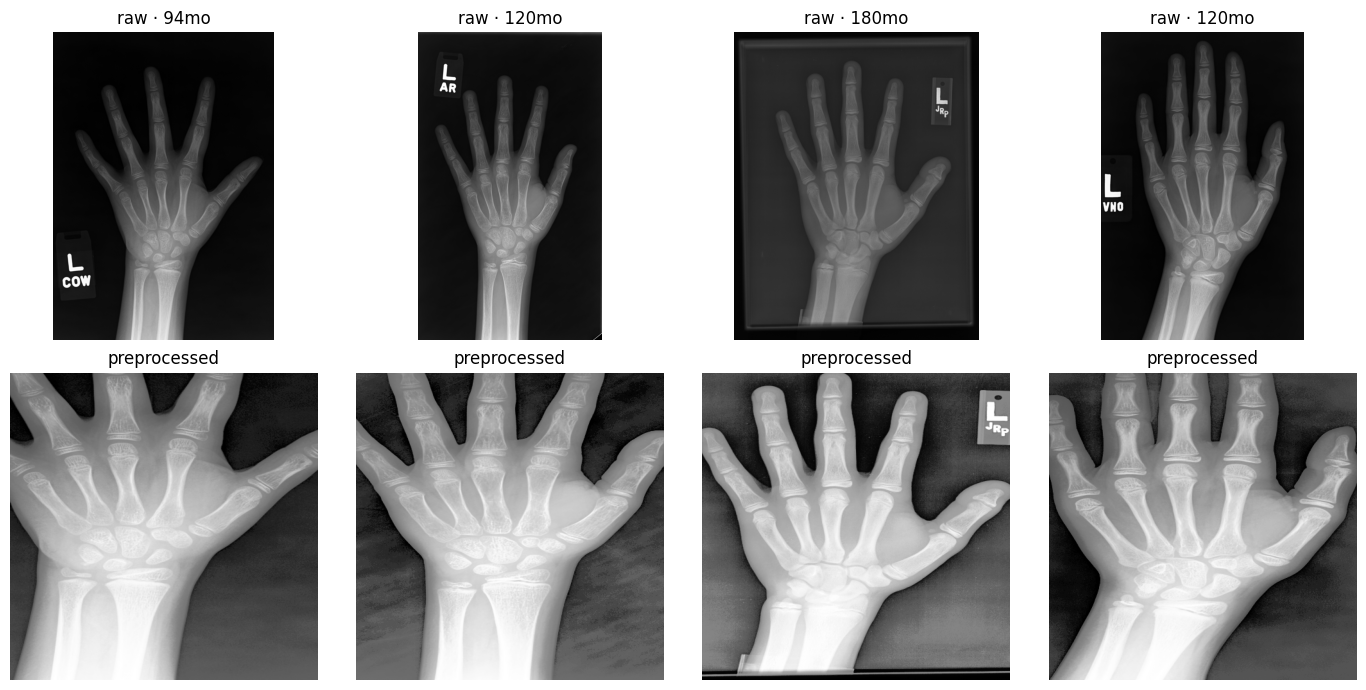

In [10]:
sample = train_df.sample(4, random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for j, (_, r) in enumerate(sample.iterrows()):
    raw = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
    pre = imread_kr(CACHE_DIR/"train"/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    axes[0, j].imshow(raw, cmap="gray"); axes[0, j].set_title(f"raw · {int(r.boneage)}mo"); axes[0, j].axis("off")
    axes[1, j].imshow(pre, cmap="gray"); axes[1, j].set_title("preprocessed"); axes[1, j].axis("off")
plt.tight_layout(); plt.show()

---
# PART 2 · 학습 설정 ⚙️  *(하이퍼파라미터를 여기서 바꾸고, 이 파트부터 아래로 재실행)*

In [11]:
# ── 하이퍼파라미터 (여기만 바꿔 재실험) ───────────────────────────────
BATCH_SIZE     = 16       # OOM 시 8
EPOCHS         = 100     
LR             = 1e-4
WEIGHT_DECAY   = 1e-5
FREEZE_BACKBONE= False    # 미세조정(False)=최고성능 / 동결(True)=빠름·안정
BILINEAR_NORM  = False    # 논문 생략(≤0.02개월). 학습 불안정 시 True
GENDER_EMB_DIM = 16
REDUCE_1, REDUCE_2 = 512, 128
NUM_WORKERS    = 0        # Windows+Jupyter 안전값(.py에선 4+ 권장)
USE_AMP        = True
RESUME         = False    # last.pt에서 이어서 학습하려면 True
EARLY_STOP_PATIENCE = 15 
MIN_DELTA           = 0.01# 개선으로 인정할 최소 MAE 감소(개월)
# ──────────────────────────────────────────────────────────────────

ARCH = {"REDUCE_1": REDUCE_1, "REDUCE_2": REDUCE_2, "GENDER_EMB_DIM": GENDER_EMB_DIM,
        "BILINEAR_NORM": BILINEAR_NORM, "IMG_SIZE": IMG_SIZE}
print("설정:", ARCH, "| batch", BATCH_SIZE, "| epochs", EPOCHS, "| resume", RESUME)

설정: {'REDUCE_1': 512, 'REDUCE_2': 128, 'GENDER_EMB_DIM': 16, 'BILINEAR_NORM': False, 'IMG_SIZE': 480} | batch 16 | epochs 100 | resume False


In [12]:
# 데이터로더
train_loader = DataLoader(BoneAgeDataset(train_df, "train", train_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(BoneAgeDataset(val_df, "val", eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print("배치 수: train", len(train_loader), "| val", len(val_loader))

배치 수: train 788 | val 90


In [13]:
# 모델·옵티마이저·스케줄러 (RESUME이면 last.pt에서 복원)
model     = build_model(ARCH, pretrained=True, freeze=FREEZE_BACKBONE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=3)
scaler    = torch.amp.GradScaler("cuda", enabled=USE_AMP)

if RESUME and LAST_CKPT.exists():
    ck = torch.load(LAST_CKPT, map_location=device)
    model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
    scheduler.load_state_dict(ck["scheduler"]); scaler.load_state_dict(ck["scaler"])
    start_epoch = ck["epoch"] + 1; best_val = ck["best_val"]; history = ck["history"]
    epochs_no_improve = ck.get("no_improve", 0)
    print(f"🔄 재개: epoch {start_epoch}부터 · best_val {best_val:.2f} · 개선정체 {epochs_no_improve}")
else:
    start_epoch, best_val, epochs_no_improve = 1, float("inf"), 0
    history = {"train_mae": [], "val_mae": []}
    print("🆕 새로 학습 시작")

n_params = sum(p.numel() for p in model.parameters())/1e6
print(f"파라미터 {n_params:.1f}M (논문 ≈23.9M)")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\Win11Pro/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 104M/104M [00:01<00:00, 71.0MB/s]
C:\project\python_source\PyTorch02\.venv\Lib\site-packages\torchvision\models\feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


🆕 새로 학습 시작
파라미터 22.9M (논문 ≈23.9M)


---
# PART 3 · 학습  *(best 즉시 저장 · 조기 종료 · 중단 재개)*
- best.pt: 검증 MAE 최저 순간 저장 → PART 4가 이걸 로드
- last.pt: 매 에폭 저장(조기종료 카운터 포함) → `RESUME=True`로 재개
- **조기 종료**: 검증 MAE가 `EARLY_STOP_PATIENCE` 에폭 연속 `MIN_DELTA` 이상 개선되지 않으면 자동 중단(스케줄러가 LR을 먼저 낮춘 뒤에도 정체하면 멈춤).
- Kernel 정지 버튼을 눌러도 `KeyboardInterrupt`를 잡아 last.pt를 남깁니다.

In [ ]:
criterion = nn.L1Loss()
best_epoch = start_epoch - epochs_no_improve   # best가 나온 에폭(로그용)
try:
    for epoch in range(start_epoch, EPOCHS + 1):
        model.train(); run_abs, seen = 0.0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}")
        for x, g, yn, ym in pbar:
            x, g, yn = x.to(device), g.to(device), yn.to(device).squeeze(1)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                pred = model(x, g); loss = criterion(pred, yn)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            run_abs += mae_months(pred, ym, AGE_MEAN, AGE_STD); seen += x.size(0)
            pbar.set_postfix(train_mae=f"{run_abs/seen:.2f}")

        tr_mae = run_abs / seen
        va_mae = evaluate(model, val_loader, AGE_MEAN, AGE_STD, USE_AMP)
        scheduler.step(va_mae)
        history["train_mae"].append(tr_mae); history["val_mae"].append(va_mae)

        # 개선 판정(MIN_DELTA 이상 감소해야 개선으로 인정)
        if va_mae < best_val - MIN_DELTA:
            best_val = va_mae; epochs_no_improve = 0; best_epoch = epoch
            save_checkpoint(BEST_CKPT, model, ARCH, AGE_MEAN, AGE_STD, best_val=best_val)
            flag = f"✔ best 저장 (val {best_val:.2f})"
        else:
            epochs_no_improve += 1
            flag = f"개선 없음 {epochs_no_improve}/{EARLY_STOP_PATIENCE}"
        print(f"  → train {tr_mae:.2f} · val {va_mae:.2f} · lr {optimizer.param_groups[0]['lr']:.1e} · {flag}")

        # 매 에폭 last 저장(조기종료 카운터 포함) + history 저장
        save_checkpoint(LAST_CKPT, model, ARCH, AGE_MEAN, AGE_STD,
                        optimizer, scheduler, scaler, epoch, best_val, history,
                        no_improve=epochs_no_improve)
        json.dump(history, open(HISTORY_JSON, "w"))

        # 조기 종료 (EARLY_STOP_PATIENCE < 0 이면 비활성)
        if EARLY_STOP_PATIENCE >= 0 and epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"\n⏹ 조기 종료: {EARLY_STOP_PATIENCE}에폭 연속 개선 없음 "
                  f"· 최고 MAE {best_val:.2f} @ epoch {best_epoch}")
            break
    else:
        print(f"\n🏁 정상 종료(전체 {EPOCHS}에폭) · 최고 검증 MAE {best_val:.2f} @ epoch {best_epoch} (논문 목표 4.10)")
except KeyboardInterrupt:
    save_checkpoint(LAST_CKPT, model, ARCH, AGE_MEAN, AGE_STD,
                    optimizer, scheduler, scaler, epoch, best_val, history,
                    no_improve=epochs_no_improve)
    json.dump(history, open(HISTORY_JSON, "w"))
    print(f"\n⏸ 중단 감지 — last.pt 저장(epoch {epoch}). PART 2에서 RESUME=True로 재개하세요.")

Epoch 01/100:   0%|          | 0/788 [00:00<?, ?it/s]

  → train 16.21 · val 10.12 · lr 1.0e-04 · ✔ best 저장 (val 10.12)


Epoch 02/100:   0%|          | 0/788 [00:00<?, ?it/s]

  → train 11.18 · val 10.17 · lr 1.0e-04 · 개선 없음 1/15


Epoch 03/100:   0%|          | 0/788 [00:00<?, ?it/s]

...

Epoch 21/100:   0%|          | 0/788 [00:00<?, ?it/s]

  → train 5.09 · val 8.13 · lr 2.5e-05 · 개선 없음 6/15


Epoch 22/100:   0%|          | 0/788 [00:00<?, ?it/s]

  → train 4.95 · val 8.30 · lr 2.5e-05 · 개선 없음 7/15


Epoch 23/100:   0%|          | 0/788 [00:00<?, ?it/s]

---
# PART 4 · 평가·설명·추론  *(학습 없이 저장된 best.pt만 로드 — 다른 사람도 이 파트만 실행 가능)*
> 이 셀을 먼저 실행하면 `eval_model`이 준비됩니다. 단일 이미지 추론(맨 아래)은 `best.pt`+이미지 1장이면 됩니다.

In [ ]:
assert BEST_CKPT.exists(), "best.pt 없음 — PART 3을 먼저 실행하거나 체크포인트를 받아 checkpoints/에 두세요."
ck = torch.load(BEST_CKPT, map_location=device)
eval_model = build_model(ck["arch"], pretrained=False)
eval_model.load_state_dict(ck["model"]); eval_model.eval()
EM_MEAN, EM_STD, EM_IMG = ck["age_mean"], ck["age_std"], ck["arch"]["IMG_SIZE"]
print(f"✅ best.pt 로드 완료 · 정규화 {EM_MEAN:.1f}±{EM_STD:.1f} · IMG {EM_IMG}")

### 4-1. 학습 곡선 (history.json 로드 · 논문 그림 8)

In [ ]:
hist = json.load(open(HISTORY_JSON)) if HISTORY_JSON.exists() else history
ep = range(1, len(hist["train_mae"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(ep, hist["train_mae"], "-o", ms=3, label="train MAE")
plt.plot(ep, hist["val_mae"],   "-o", ms=3, label="val MAE")
plt.axhline(4.10, ls="--", c="green", label="paper 4.10")
plt.xlabel("Epoch"); plt.ylabel("MAE (months)"); plt.title("Validation MAE vs Epoch")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### 4-2. 검증셋 예측 · 산점도 · 연령대별 MAE (논문 표 6)

In [ ]:
# PART 2를 안 돌렸어도 독립 실행되도록 val_loader를 여기서 구성
_val_loader = DataLoader(BoneAgeDataset(val_df, "val", eval_tf),
    batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

preds, trues = [], []
with torch.no_grad():
    for x, g, yn, ym in tqdm(_val_loader, desc="predict"):
        x, g = x.to(device), g.to(device)
        with torch.amp.autocast("cuda", enabled=True):
            p = eval_model(x, g)
        preds.append(p.cpu()*EM_STD + EM_MEAN); trues.append(ym.squeeze(1))
preds = torch.cat(preds).numpy(); trues = torch.cat(trues).numpy()

overall = np.abs(preds - trues).mean()
print(f"전체 검증 MAE {overall:.2f} 개월 · 편향 {np.mean(preds-trues):+.2f}")

plt.figure(figsize=(6, 6)); plt.scatter(trues, preds, s=8, alpha=.4)
lim = [0, max(trues.max(), preds.max())+5]; plt.plot(lim, lim, "r--")
plt.xlabel("True (months)"); plt.ylabel("Pred (months)")
plt.title(f"Validation · MAE={overall:.2f}mo"); plt.tight_layout(); plt.show()

bins, labels = [0,48,96,144,192,10**5], ["0-4y","4-8y","8-12y","12-16y",">16y"]
print(f"{'group':>7} | {'N':>4} | {'MAE':>5} | {'bias':>6}")
for lo, hi, lab in zip(bins[:-1], bins[1:], labels):
    m = (trues>=lo) & (trues<hi)
    if m.sum(): print(f"{lab:>7} | {m.sum():>4} | {np.abs(preds[m]-trues[m]).mean():>5.2f} | {np.mean(preds[m]-trues[m]):>+6.2f}")

### 4-3. Grad-CAM (논문 그림 11)

In [ ]:
class GradCAM:
    '''Mixed_7c 특징 기준 Grad-CAM (회귀 출력).'''
    def __init__(self, model):
        self.model = model; self.feat = self.grad = None
        tgt = dict(model.backbone.named_modules())["Mixed_7c"]
        tgt.register_forward_hook(lambda m,i,o: setattr(self, "feat", o.detach()))
        tgt.register_full_backward_hook(lambda m,gi,go: setattr(self, "grad", go[0].detach()))
    def __call__(self, x, g):
        self.model.eval(); out = self.model(x, g); self.model.zero_grad(); out.sum().backward()
        w = self.grad.mean(dim=(2,3), keepdim=True)
        cam = F.relu((w*self.feat).sum(1))[0]
        cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
        return cam.cpu().numpy(), out.item()

cam_engine = GradCAM(eval_model)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (_, r) in zip(axes, val_df.sample(4, random_state=1).iterrows()):
    g = imread_kr(CACHE_DIR/"val"/f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    x = eval_tf(np.stack([g]*3, -1)).unsqueeze(0).to(device)
    gd = torch.tensor([[r["male"]]], dtype=torch.float32, device=device)
    cam, pn = cam_engine(x, gd); pred_month = pn*EM_STD + EM_MEAN
    heat = cv2.applyColorMap(np.uint8(255*cv2.resize(cam,(EM_IMG,EM_IMG))), cv2.COLORMAP_JET)
    over = cv2.addWeighted(cv2.cvtColor(g, cv2.COLOR_GRAY2BGR), 0.55, heat, 0.45, 0)
    ax.imshow(cv2.cvtColor(over, cv2.COLOR_BGR2RGB))
    ax.set_title(f"pred {pred_month:.0f}/true {int(r.boneage)}mo"); ax.axis("off")
plt.tight_layout(); plt.show()

### 4-4. 단일 이미지 추론 (완전 독립 — best.pt + 이미지 1장이면 끝)
다른 사람은 `best.pt`만 받아 `checkpoints/`에 두고, PART 0 실행 후 이 함수만 호출하면 됩니다.

In [ ]:
def predict_bone_age(image_path, is_male, ckpt_path=BEST_CKPT):
    '''원본 X-ray 경로 + 성별(True=남) → 골연령(개월). 전처리·모델 모두 체크포인트 기준으로 자체 완결.'''
    ck = torch.load(ckpt_path, map_location=device)
    m = build_model(ck["arch"], pretrained=False); m.load_state_dict(ck["model"]); m.eval()
    g = imread_kr(image_path, cv2.IMREAD_GRAYSCALE)
    if g is None: raise FileNotFoundError(image_path)
    pre = preprocess(g, size=ck["arch"]["IMG_SIZE"])
    x = eval_tf(np.stack([pre]*3, -1)).unsqueeze(0).to(device)
    gd = torch.tensor([[float(is_male)]], dtype=torch.float32, device=device)
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=True):
        pn = m(x, gd).item()
    return pn * ck["age_std"] + ck["age_mean"]

# 예시:
# months = predict_bone_age(VAL_IMG_DIR / "1386.png", is_male=True)
# print(f"예측 골연령: {months:.1f} 개월")
print("추론 함수 준비 완료 · best.pt:", BEST_CKPT)